In [84]:
import pandas as pd
import yfinance as yf
import numpy as np
from scipy.stats import norm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

# Stock Risk Analysis

#### The goal of this project is to analyze the risk of holding a group of investment, specifically nine U.S stocks (AAPL, GOOG, COST, CVX, JNJ, JPM, MCD, NVDA) and one gold etf (GLD) using a 10-year data from August 29, 2016 to August 28, 2026.

## Stage 1: Download Data from Yahoo Finance

In [85]:
tickers = ["AAPL", "GOOG", "COST", "CVX", "JNJ", "JPM", "MCD", "NVDA", "GLD"]

df = yf.download(tickers, start="2016-08-29", end="2026-08-28")

# Saving Close Column as its own dataframe (Contains all tickers as its own column)
close_prices = df["Close"]

[*********************100%***********************]  9 of 9 completed


## Stage 2: Risk Assessment of Individual Stock

### Calculate Mean, Standard Deviation, and Skew

In [86]:
# Piece 1: log returns + drop first NaN row
log_returns = np.log(close_prices / close_prices.shift(1))
log_returns = log_returns.dropna()   # <- method to drop NaN rows

# Piece 2: build summary table
summary = pd.concat([log_returns.mean(), log_returns.std(), log_returns.skew()], axis=1)
summary = summary.rename(columns={0: 'Mean', 1: 'Standard Deviation', 2: 'Skew'})

# Piece 3: annualize mean and std columns only
summary['Mean'] = summary['Mean'] * 252
summary['Standard Deviation'] = summary['Standard Deviation'] * np.sqrt(252)

print(summary)

            Mean  Standard Deviation      Skew
Ticker                                        
AAPL    0.256364            0.291216 -0.114653
COST    0.191521            0.221379 -0.533034
CVX     0.109695            0.295029 -1.090139
GLD     0.121161            0.163233 -0.719254
GOOG    0.218445            0.294283 -0.111310
JNJ     0.107112            0.188385 -0.403720
JPM     0.193488            0.273031 -0.092013
MCD     0.105671            0.205393 -0.238365
NVDA    0.502486            0.497605  0.079450


### Translate Standard Deviation and Skew into Risk

**By volatility alone (annualized std dev):**
NVDA is by far the most volatile (49.8%), followed by CVX, GOOG, and AAPL 
in the 29-30% range. GLD is the calmest by a wide margin (16.4%).

**But volatility alone is misleading.**
Checking mean vs. std across all 9 tickers: every single stock has mean < std.
This is a general feature of daily returns (short-term noise dwarfs long-term 
drift) — not something that distinguishes any one stock from the rest.

**Skew reveals a different risk story.**
GLD has the lowest volatility (16.4%) but a strongly negative skew (-0.725) —
almost as negative as CVX (-1.092), the single most negative in the basket.
Compare this to JPM: nearly double GLD's volatility (27.3%) but a much more 
symmetric skew (-0.092).

**Conclusion:** GLD is the calmest asset day-to-day, but its negative skew means 
its rare "bad days" are disproportionately severe relative to its normal behavior — 
a risk that standard deviation alone doesn't capture. "Riskiest" depends on the 
definition: lowest day-to-day volatility (GLD) is not the same as lowest exposure 
to a severe, asymmetric crash (arguably JPM, given its much more symmetric tail 
despite higher volatility).

### Estimate the Probability of a >5% Single-Day Drop

In [87]:
## Convert Mean and Standard Deviation back to daily scale (Z score stays unimpacted by annual scale)
summary['Mean'] = summary['Mean'] / 252
summary['Standard Deviation'] = summary['Standard Deviation'] / np.sqrt(252)
summary["z score"] = (-0.05 - summary['Mean'])/summary['Standard Deviation']

In [88]:
summary["A Single-Day 5% Drop Probability (Displayed in %)"] = norm.cdf(summary["z score"]) * 100
print(summary[["A Single-Day 5% Drop Probability (Displayed in %)"]])

        A Single-Day 5% Drop Probability (Displayed in %)
Ticker                                                   
AAPL                                             0.270947
COST                                             0.013639
CVX                                              0.332625
GLD                                              0.000046
GOOG                                             0.303562
JNJ                                              0.001073
JPM                                              0.157999
MCD                                              0.004873
NVDA                                             4.858775


#### Finding

NVDA has the highest probability of its price dropping 5% or more in a single day. On the other hand, GLD has the lowest probability in this category at only 0.000046%. However, there is a caveat to this number. GLD has a skew of -0.7192 vs NVDA standing at 0.079. This shows that when there is an outliers, GLD's tail is longer on the left side (moving in a negative direction), whereas NVDA's tail is longer on the right side (moving in a positive direction). Probability at this category alone does not concretely conclude that NVDA is a riskier stock to own. Most of the remaining stocks see a close-to-zero% to 0.4% chance. This means beside NVDA, we will unlikely see an individual stock in our portfolio drops its price more than 5% in a single day. Even with NVDA, if we look at a 100-day scale, we will likely see a 5% or more drop in 5/100 days. 

## Stage 3: Relationship Between Stocks

### Calculate Covariance of Each Pair of Stocks

In [89]:
cov_matrix = log_returns.cov()
print(cov_matrix)

Ticker      AAPL      COST       CVX       GLD      GOOG       JNJ       JPM  \
Ticker                                                                         
AAPL    0.000337  0.000118  0.000105  0.000011  0.000198  0.000063  0.000127   
COST    0.000118  0.000194  0.000055  0.000009  0.000098  0.000057  0.000070   
CVX     0.000105  0.000055  0.000345  0.000011  0.000095  0.000068  0.000177   
GLD     0.000011  0.000009  0.000011  0.000106  0.000017  0.000006 -0.000006   
GOOG    0.000198  0.000098  0.000095  0.000017  0.000344  0.000050  0.000125   
JNJ     0.000063  0.000057  0.000068  0.000006  0.000050  0.000141  0.000066   
JPM     0.000127  0.000070  0.000177 -0.000006  0.000125  0.000066  0.000296   
MCD     0.000091  0.000064  0.000091  0.000009  0.000075  0.000061  0.000093   
NVDA    0.000305  0.000153  0.000133  0.000019  0.000310  0.000033  0.000177   

Ticker       MCD      NVDA  
Ticker                      
AAPL    0.000091  0.000305  
COST    0.000064  0.000153  
CVX

### Correlation Between Each Pair of Stocks

In [90]:
corr_matrix = log_returns.corr()
print(corr_matrix)

Ticker      AAPL      COST       CVX       GLD      GOOG       JNJ       JPM  \
Ticker                                                                         
AAPL    1.000000  0.459771  0.308931  0.057179  0.583257  0.289422  0.403180   
COST    0.459771  1.000000  0.210542  0.060444  0.379240  0.347217  0.291258   
CVX     0.308931  0.210542  1.000000  0.055033  0.275739  0.306486  0.555189   
GLD     0.057179  0.060444  0.055033  1.000000  0.087219  0.051687 -0.031167   
GOOG    0.583257  0.379240  0.275739  0.087219  1.000000  0.226639  0.392538   
JNJ     0.289422  0.347217  0.306486  0.051687  0.226639  1.000000  0.324400   
JPM     0.403180  0.291258  0.555189 -0.031167  0.392538  0.324400  1.000000   
MCD     0.381711  0.356891  0.377030  0.068804  0.314091  0.395148  0.419518   
NVDA    0.530191  0.350519  0.229087  0.059062  0.533014  0.087674  0.329105   

Ticker       MCD      NVDA  
Ticker                      
AAPL    0.381711  0.530191  
COST    0.356891  0.350519  
CVX

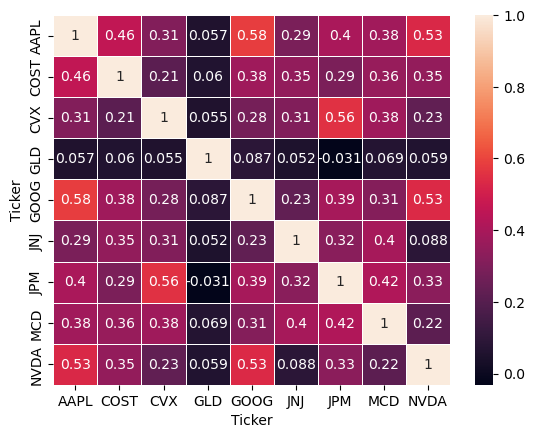

In [91]:
sns.heatmap(corr_matrix, annot=True, linewidth=.5)
plt.show()

#### Finding

Every pair of stocks has a positive correlation except for JPM and GLD. This is the only pair with a weak negative correlation of -0.031. GOOG & AAPL, NVDA & AAPL, and JPM & CVX are pairs with moderate positive correlation of >0.50, suggesting they tend to move together. GLD has a weak positive correlation (< 0.09) with the rest of the stocks. The correlation heatmap demonstrates that eight out of nine stocks in our portfolio show a consistent tendency to move in the same direction, to varying degrees, except for GLD. As seen in Stage 4, removing GLD from our portfolio, our portfolio annual volatility is increased from 17.06% to 18.93%. Thus, diversifying our portfolio should be considered and highly recommended. 

## Stage 4: Risk Assessment of the Whole Portfolio

### Calculate the Portfolio Variance

In [92]:
w_equal = np.array([1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9, 1/9])
# Convert Covariance into a numpy array
cov_array = np.array(cov_matrix)

In [93]:
portfolio_variance = w_equal @ cov_array @ w_equal
portfolio_std_daily = np.sqrt(portfolio_variance)
portfolio_std_annualized = portfolio_std_daily * np.sqrt(252)
print("Portfolio variance: ", portfolio_variance)
print("Portfolio standard deviation (daily): ", portfolio_std_daily)
print("Portfolio standard deviation (annual): ", portfolio_std_annualized)

Portfolio variance:  0.00011554340666958501
Portfolio standard deviation (daily):  0.010749111901435626
Portfolio standard deviation (annual):  0.17063686143601983


### Applying Different Weights

#### Correlated Pair (AAPL and GOOG) vs Diversified Pair (GLD and JPM)

The correlation matrix shows that AAPL and GOOG has a moderate positive correlation score of 0.58 (highest among other pairs of stocks). By placing weight only on these two stocks, we want to assess the volatility of only owning correlated stocks in our portfolio, meaning stocks that in general move together in the same direction. 

On the other hand, GLD and JPM show a weak negative correlation of -0.031, suggesting they tend to move slight in opposite directions. By placing weight only on these two stocks, we want to assess the volatility of diversifying our portfolio with stocks that don't generally move together in the same direction.

In [94]:
## Weight AAPL and GOOG each 50% and the rest at 0
w_correlated_pair = np.array([0.5,0,0,0,0.5,0,0,0,0])
w_diversified_pair = np.array([0,0,0,0.5,0,0,0.5,0,0])

variance_correlated = w_correlated_pair @ cov_array @ w_correlated_pair
std_daily_correlated = np.sqrt(variance_correlated)
std_annual_correlated = std_daily_correlated * np.sqrt(252)

## Weight GLD and JPM each 50% and the rest at 0
variance_diversified = w_diversified_pair @ cov_array @ w_diversified_pair
std_daily_diversified = np.sqrt(variance_diversified)
std_annual_diversified = std_daily_diversified * np.sqrt(252)

print("Correlated pair (AAPL/GOOG) variance: ", variance_correlated)
print("Correlated pair (AAPL/GOOG) daily std: ", std_daily_correlated)
print("Correlated pair (AAPL/GOOG) annual std: ", std_annual_correlated)

print("Diversified pair (GLD/JPM) variance: ", variance_diversified)
print("Diversified pair (GLD/JPM) daily std: ", std_daily_diversified)
print("Diversified pair (GLD/JPM) annual std: ", std_annual_diversified)

Correlated pair (AAPL/GOOG) variance:  0.00026922543508733465
Correlated pair (AAPL/GOOG) daily std:  0.016408090537516382
Correlated pair (AAPL/GOOG) annual std:  0.2604703623102028
Diversified pair (GLD/JPM) variance:  9.763164347689896e-05
Diversified pair (GLD/JPM) daily std:  0.009880872607057485
Diversified pair (GLD/JPM) annual std:  0.15685398992750724


#### Finding

Undiversified stock portfolio is more volatile than a diversified portfolio. As seen above, the standard deviation of the correlated pair (AAPL/GOOG) is 26.04%, whereas the standard deviation of the diversified pair (GLD/JPM) is 15.68%. Concentrating in the correlated pair increases volatility by 66.07% relative to the diversified pair.

#### Removing GLD vs Removing AAPL

GLD has a weak correlation with every other ticker (ranging from low negative to low positive). On the contrary, AAPL has a weak to moderate positive correlation with every other stocks (excluding GLD).

First, we want to remove weight from the GLD, and calculate the volatility. Then, we will repeat the same calculation, but this time, removing weight from the AAPL instead. Finally, we will assess the impact of these removals has on our portfolio.

In [95]:
w_remove_gld = np.array([1/8,1/8,1/8,0,1/8,1/8,1/8,1/8,1/8])
variance_remove_gld = w_remove_gld @ cov_array @ w_remove_gld
std_remove_gld = np.sqrt(variance_remove_gld)
annual_std_remove_gld = std_remove_gld * np.sqrt(252)

print("Portfolio Variance (Removed GLD): ",variance_remove_gld)
print("Portfolio Standard Deviation (Removed GLD): ",std_remove_gld)
print("Portfolio Annual Standard Deviation (Removed GLD): ",annual_std_remove_gld)

Portfolio Variance (Removed GLD):  0.00014222058480053528
Portfolio Standard Deviation (Removed GLD):  0.011925627228810035
Portfolio Annual Standard Deviation (Removed GLD):  0.1893134632553504


In [96]:
w_remove_aapl = np.array([0,1/8,1/8,1/8,1/8,1/8,1/8,1/8,1/8])
variance_remove_aapl = w_remove_aapl @ cov_array @ w_remove_aapl
std_remove_aapl = np.sqrt(variance_remove_aapl)
annual_std_remove_aapl = std_remove_aapl * np.sqrt(252)

print("Portfolio Variance (Removed AAPL): ",variance_remove_aapl)
print("Portfolio Standard Deviation (Removed AAPL): ",std_remove_aapl)
print("Portfolio Annual Standard Deviation (Removed AAPL): ",annual_std_remove_aapl)

Portfolio Variance (Removed AAPL):  0.00010917031653512926
Portfolio Standard Deviation (Removed AAPL):  0.01044846000782552
Portfolio Annual Standard Deviation (Removed AAPL):  0.16586416058586187


#### Finding

Removing GLD from our portfolio increases the annual volatility from 17.06% to 18.93% (a 1.87% increase). 
Removing AAPL from our portfolio lowers the annual volatility from 17.06% to 16.59% (a 0.48% decrease). 

GLD's removal has approximately 4 times more impact on the portfolio's volatility than AAPL's removal although both hold the same 1/9 weight in the portfolio.

## Stage 5: Build a Linear Regression Model

### Calculating the Average 20-days Rolling Volume

In [97]:
volume = df['Volume']
rolling_volume = volume.rolling(window=20).mean()

### Calculating the 20-days Rolling Volatility

In [98]:
rolling_vol = log_returns.rolling(window=20).std()

In [99]:
forward_vol = log_returns[::-1].rolling(window=20).std()[::-1]

### Reshaping Data

In [100]:
# Reshape volume data from wide to long format
rolling_volume_reset = rolling_volume.reset_index()
rolling_volume_long = pd.melt(rolling_volume_reset, id_vars="Date", var_name="Ticker", value_name="Volume")
# Reshape rolling return 
rolling_vol_reset = rolling_vol.reset_index()
rolling_vol_long = pd.melt(rolling_vol_reset, id_vars="Date", var_name="Ticker", value_name="Rolling Backward Volatility")

# Reshape forward return 
forward_vol_reset = forward_vol.reset_index()
forward_vol_long = pd.melt(forward_vol_reset, id_vars="Date", var_name="Ticker", value_name="Rolling Forward Volatility")
print(forward_vol_long.head())

        Date Ticker  Rolling Forward Volatility
0 2016-08-30   AAPL                    0.016550
1 2016-08-31   AAPL                    0.016389
2 2016-09-01   AAPL                    0.016942
3 2016-09-02   AAPL                    0.016964
4 2016-09-06   AAPL                    0.016974


### Merging Rolling Return, Rolling Volume, and Forward Volume into one Dataframe

In [101]:
df_combined = pd.merge(rolling_volume_long, rolling_vol_long, on=['Date', 'Ticker'], how="inner")
df_final = pd.merge(df_combined, forward_vol_long, on=['Date', 'Ticker'], how="inner")
df_final = df_final.dropna()
print(df_final.head())

         Date Ticker       Volume  Rolling Backward Volatility  \
19 2016-09-27   AAPL  184126940.0                     0.016550   
20 2016-09-28   AAPL  185082380.0                     0.016389   
21 2016-09-29   AAPL  186327300.0                     0.016942   
22 2016-09-30   AAPL  188262820.0                     0.016964   
23 2016-10-03   AAPL  187242680.0                     0.016974   

    Rolling Forward Volatility  
19                    0.006907  
20                    0.006940  
21                    0.008780  
22                    0.008279  
23                    0.008290  


### Splitting Data for Training and Testing

In [102]:
df_sorted = df_final.sort_values("Date")
split_index = int(len(df_sorted) * 0.8)
train = df_sorted[:split_index]
test = df_sorted[split_index:]

### Fit the Training Data into the Model

In [103]:
X_train = train[["Volume","Rolling Backward Volatility"]]
y_train = train["Rolling Forward Volatility"]

X_test = test[["Volume","Rolling Backward Volatility"]]
y_test = test["Rolling Forward Volatility"]

# Scaling Feature Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [104]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)
r2 = r2_score(y_test, predictions)
print(r2)

0.378347574730326


#### Finding

Our linear regression model has an R2 score of 0.378, suggesting our model is able capture 37.83% of the variations in future volatility. In our case, our model is using the volume and rolling volatility data. Stock investing is very noisy. There are a lot of drivers and unprecedented events that would have impacted the stock's price significantly that our model can't predict, for example, in the event of COVID-19.

### Output the Coefficient

In [105]:
print(model.coef_)
print(X_train.columns)

[0.00215967 0.00527858]
Index(['Volume', 'Rolling Backward Volatility'], dtype='object')


#### Finding
As expected, rolling volatility does have a more pronounced role in predicting future volatility. Volume has a coefficient of 0.0021, while rolling backward volatility has a coefficient of 0.0052, which is approximately 2 times more. These are the scaled coefficients. 
